# Panorama de la Seguridad Informatica

Guia panoramica de las principales disciplinas, tecnicas y curiosidades del mundo de la ciberseguridad.

---

## Por que importa

- Los ciberataques costaron **$8 trillones** globalmente en 2023
- Se produce un ataque cada **39 segundos** en promedio
- El **95% de las brechas** son por error humano
- La demanda de profesionales de ciberseguridad supera la oferta en **3.5 millones** de puestos

La seguridad informatica no es solo "hackers con capucha en un sotano". Es un campo multidisciplinar que abarca redes, aplicaciones, criptografia, forense, inteligencia artificial y mucho mas.

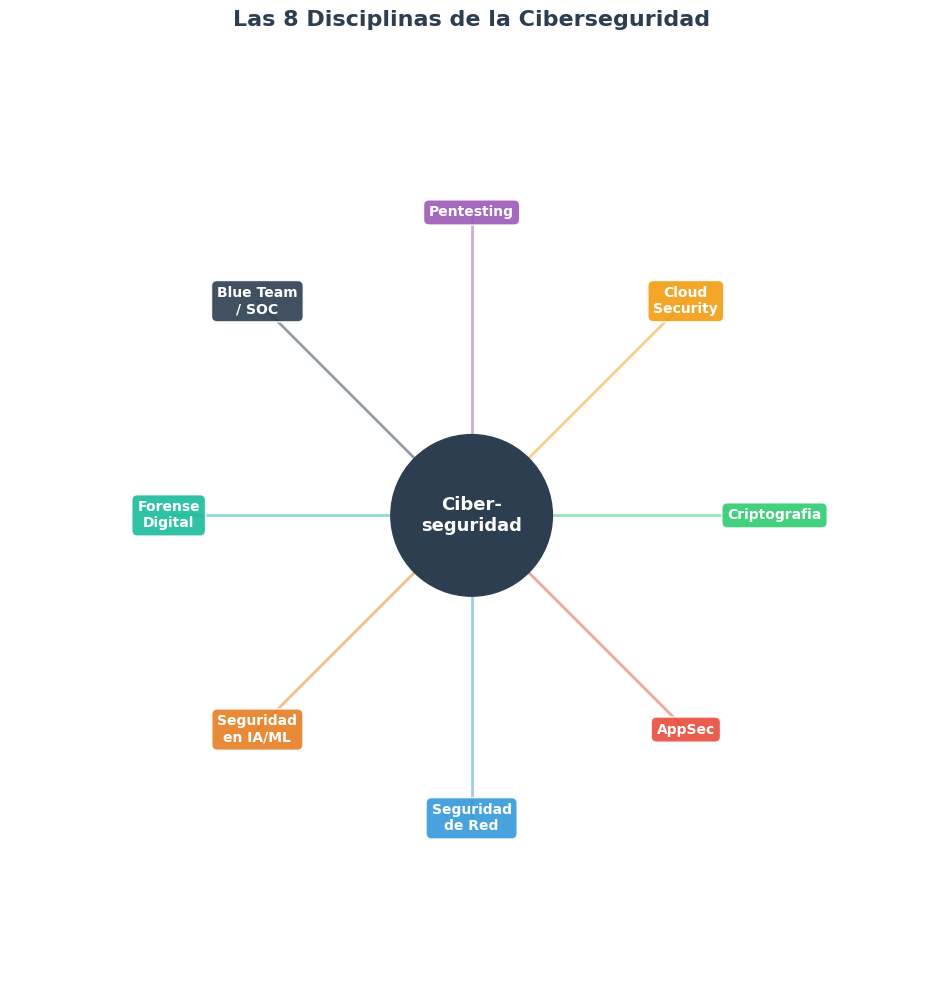

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import hashlib
import base64

# --- Configuracion de estilo ---
C_PRIMARY = '#3498db'
C_DANGER  = '#e74c3c'
C_SUCCESS = '#2ecc71'
C_DARK    = '#2c3e50'
C_ORANGE  = '#f39c12'
C_PURPLE  = '#9b59b6'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# --- Diagrama: 8 disciplinas de la ciberseguridad ---
disciplinas = [
    'Seguridad\nde Red', 'AppSec', 'Criptografia', 'Cloud\nSecurity',
    'Pentesting', 'Blue Team\n/ SOC', 'Forense\nDigital', 'Seguridad\nen IA/ML'
]
colores = [C_PRIMARY, C_DANGER, C_SUCCESS, C_ORANGE, C_PURPLE, C_DARK, '#1abc9c', '#e67e22']

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-1.6, 1.6)
ax.set_aspect('equal')
ax.axis('off')

# Centro
circle_center = plt.Circle((0, 0), 0.28, color=C_DARK, zorder=5)
ax.add_patch(circle_center)
ax.text(0, 0, 'Ciber-\nseguridad', ha='center', va='center',
        fontsize=13, fontweight='bold', color='white', zorder=6)

# Disciplinas en circulo
n = len(disciplinas)
for i, (disc, col) in enumerate(zip(disciplinas, colores)):
    angle = 2 * np.pi * i / n - np.pi / 2
    x = 1.05 * np.cos(angle)
    y = 1.05 * np.sin(angle)
    # Linea al centro
    ax.plot([0, x], [0, y], color=col, lw=2, alpha=0.5, zorder=1)
    # Caja
    bbox = dict(boxstyle='round,pad=0.4', facecolor=col, edgecolor='white', alpha=0.9)
    ax.text(x, y, disc, ha='center', va='center', fontsize=10,
            fontweight='bold', color='white', bbox=bbox, zorder=4)

plt.title('Las 8 Disciplinas de la Ciberseguridad', fontsize=16,
          fontweight='bold', color=C_DARK, pad=20)
plt.tight_layout()
plt.show()

# 1. Seguridad de Red (Network Security)

**Que es:** proteger la infraestructura de red contra accesos no autorizados, ataques y uso indebido.

## Componentes principales

- **Firewalls** -- filtran el trafico de red segun reglas predefinidas. Actuan como un guardia en la puerta: revisan cada paquete y deciden si pasa o no.
- **IDS/IPS** (Intrusion Detection/Prevention System) -- monitorizan el trafico en busca de patrones sospechosos. El IDS alerta, el IPS bloquea automaticamente.
- **VPN** (Virtual Private Network) -- crea un tunel cifrado entre dos puntos. Tu ISP ve que te conectas al servidor VPN, pero no ve que haces dentro del tunel.
- **Segmentacion de red** -- dividir la red en zonas aisladas. Si un atacante compromete la zona de invitados, no puede llegar a la zona de servidores.

## Como funciona un firewall

Un firewall evalua cada paquete contra una lista de reglas ordenadas:

1. **Reglas de entrada (inbound):** que trafico externo puede entrar a tu red
2. **Reglas de salida (outbound):** que trafico interno puede salir
3. **Whitelist vs Blacklist:** permitir solo lo conocido (mas seguro) vs bloquear solo lo conocido (mas permisivo)

Ejemplo de regla: `ALLOW TCP 443 FROM any TO 192.168.1.0/24` -- permitir HTTPS desde cualquier origen hacia la red local.

---

> **Curiosidad:** El **Morris Worm** (1988) fue el primer worm de internet. Infecto aproximadamente 6,000 de las 60,000 maquinas conectadas (el 10% de internet en ese momento). Su creador, Robert Tappan Morris, fue el primer condenado bajo la Computer Fraud and Abuse Act. Hoy es profesor en el MIT.

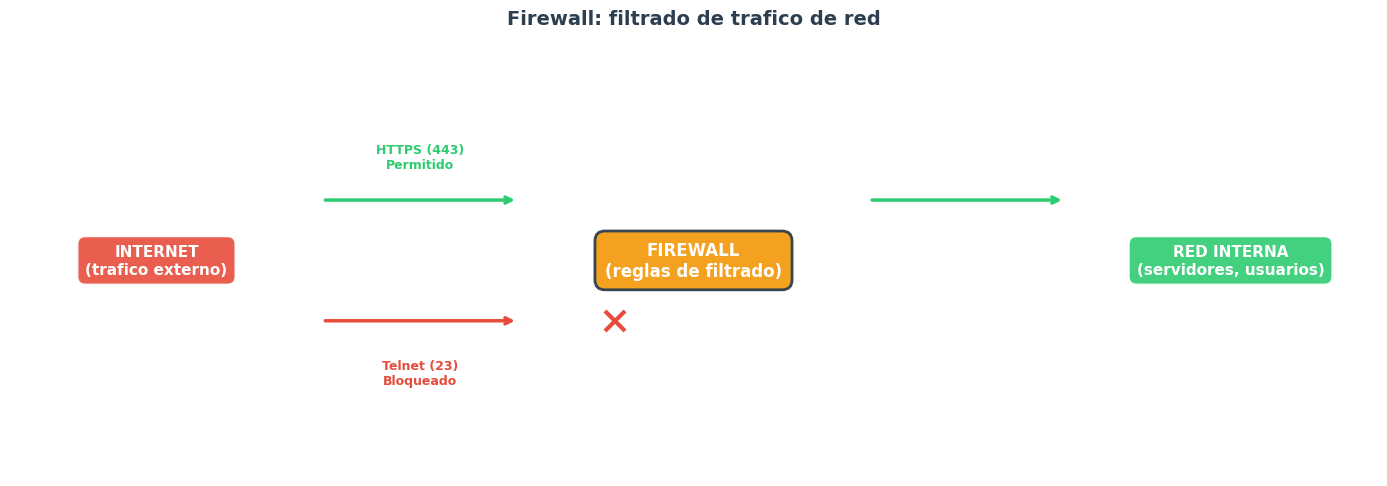

In [2]:
# --- Diagrama: Como funciona un firewall ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis('off')

# Internet
bbox_inet = dict(boxstyle='round,pad=0.5', facecolor=C_DANGER, edgecolor='white', alpha=0.9)
ax.text(1.5, 2.5, 'INTERNET\n(trafico externo)', ha='center', va='center',
        fontsize=11, fontweight='bold', color='white', bbox=bbox_inet)

# Firewall
bbox_fw = dict(boxstyle='round,pad=0.6', facecolor=C_ORANGE, edgecolor=C_DARK, linewidth=2, alpha=0.95)
ax.text(7, 2.5, 'FIREWALL\n(reglas de filtrado)', ha='center', va='center',
        fontsize=12, fontweight='bold', color='white', bbox=bbox_fw)

# Red interna
bbox_red = dict(boxstyle='round,pad=0.5', facecolor=C_SUCCESS, edgecolor='white', alpha=0.9)
ax.text(12.5, 2.5, 'RED INTERNA\n(servidores, usuarios)', ha='center', va='center',
        fontsize=11, fontweight='bold', color='white', bbox=bbox_red)

# Flecha verde (trafico permitido)
ax.annotate('', xy=(5.2, 3.2), xytext=(3.2, 3.2),
            arrowprops=dict(arrowstyle='->', color=C_SUCCESS, lw=2.5))
ax.text(4.2, 3.7, 'HTTPS (443)\nPermitido', ha='center', va='center',
        fontsize=9, color=C_SUCCESS, fontweight='bold')

ax.annotate('', xy=(10.8, 3.2), xytext=(8.8, 3.2),
            arrowprops=dict(arrowstyle='->', color=C_SUCCESS, lw=2.5))

# Flecha roja (trafico bloqueado)
ax.annotate('', xy=(5.2, 1.8), xytext=(3.2, 1.8),
            arrowprops=dict(arrowstyle='->', color=C_DANGER, lw=2.5))
ax.text(4.2, 1.2, 'Telnet (23)\nBloqueado', ha='center', va='center',
        fontsize=9, color=C_DANGER, fontweight='bold')

ax.plot(6.2, 1.8, 'x', markersize=15, color=C_DANGER, markeredgewidth=3)

plt.title('Firewall: filtrado de trafico de red', fontsize=14,
          fontweight='bold', color=C_DARK, pad=15)
plt.tight_layout()
plt.show()

# 2. Seguridad de Aplicaciones (AppSec)

## OWASP Top 10 (2021)

Las 10 vulnerabilidades web mas comunes segun la Open Web Application Security Project:

| # | Vulnerabilidad | Descripcion |
|---|---|---|
| 1 | **Broken Access Control** | Usuarios acceden a recursos sin autorizacion |
| 2 | **Cryptographic Failures** | Datos sensibles sin cifrar o mal cifrados |
| 3 | **Injection** | SQL, NoSQL, OS command injection |
| 4 | **Insecure Design** | Fallas de arquitectura, no de implementacion |
| 5 | **Security Misconfiguration** | Configuraciones por defecto, permisos excesivos |
| 6 | **Vulnerable Components** | Dependencias desactualizadas con CVEs conocidos |
| 7 | **Auth Failures** | Autenticacion debil, sesiones mal gestionadas |
| 8 | **Data Integrity Failures** | Software sin verificar integridad (supply chain) |
| 9 | **Logging Failures** | Sin logs o monitoreo, no se detectan ataques |
| 10 | **SSRF** | Server-Side Request Forgery, el servidor hace peticiones maliciosas |

## SQL Injection -- paso a paso

**Login normal:**
```sql
SELECT * FROM users WHERE user='admin' AND pass='1234'
```

**Ataque -- el usuario escribe en el campo "user":**
```
admin' OR '1'='1' --
```

**Query resultante:**
```sql
SELECT * FROM users WHERE user='admin' OR '1'='1' --' AND pass=''
```

El `OR '1'='1'` **siempre es verdadero**. El `--` comenta el resto de la query. Resultado: acceso sin contrasena.

## Cross-Site Scripting (XSS)

Un atacante inyecta codigo JavaScript en un campo de formulario:
```html
<script>alert('hacked')</script>
```
Si la aplicacion no sanitiza la entrada, ese script se ejecuta en el navegador de **otros usuarios** que visiten la pagina, pudiendo robar cookies de sesion.

---

> **Curiosidad:** **Equifax** (2017) -- 147 millones de datos personales filtrados por una vulnerabilidad conocida en Apache Struts que **no fue parcheada durante 2 meses** a pesar de existir el parche. Multa de $700M. La leccion: actualizar dependencias no es opcional.

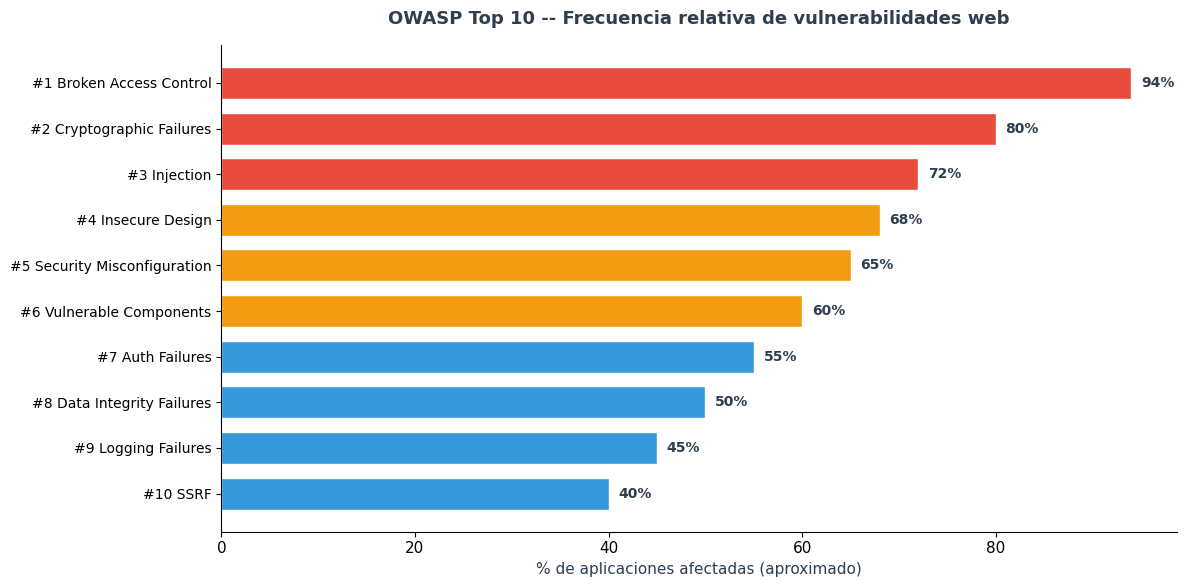

In [3]:
# --- OWASP Top 10: frecuencia relativa ---
vulnerabilities = [
    'Broken Access Control', 'Cryptographic Failures', 'Injection',
    'Insecure Design', 'Security Misconfiguration', 'Vulnerable Components',
    'Auth Failures', 'Data Integrity Failures', 'Logging Failures', 'SSRF'
]
# Frecuencia relativa aproximada (% de aplicaciones afectadas)
frequencies = [94.0, 80.0, 72.0, 68.0, 65.0, 60.0, 55.0, 50.0, 45.0, 40.0]

colors_owasp = [C_DANGER if f > 70 else C_ORANGE if f > 55 else C_PRIMARY for f in frequencies]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(vulnerabilities)), frequencies, color=colors_owasp, edgecolor='white', height=0.7)
ax.set_yticks(range(len(vulnerabilities)))
ax.set_yticklabels([f"#{i+1} {v}" for i, v in enumerate(vulnerabilities)], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('% de aplicaciones afectadas (aproximado)', fontsize=11, color=C_DARK)
ax.set_title('OWASP Top 10 -- Frecuencia relativa de vulnerabilidades web',
             fontsize=13, fontweight='bold', color=C_DARK, pad=15)

for bar, freq in zip(bars, frequencies):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{freq:.0f}%', va='center', fontsize=10, fontweight='bold', color=C_DARK)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# 3. Criptografia

La criptografia es la ciencia de proteger informacion transformandola en un formato ilegible para quienes no poseen la clave adecuada.

## Criptografia simetrica (AES)

**Una sola clave** cifra y descifra. Rapida y eficiente. Se usa para datos en reposo (archivos, bases de datos).

**Analogia:** un candado con una sola llave. Ambas partes (emisor y receptor) tienen una copia identica de la llave. El problema: como envias la llave de forma segura por primera vez?

## Criptografia asimetrica (RSA)

**Dos claves:** una publica (cifrar) y una privada (descifrar). Mas lenta, pero resuelve el problema de distribucion de claves.

**Analogia:** un buzon de correo. Cualquiera puede meter cartas por la ranura (clave publica), pero solo tu tienes la llave para abrir el buzon y leerlas (clave privada).

En la practica se combinan: RSA intercambia una clave simetrica temporal, y luego AES cifra los datos con esa clave. Esto es exactamente lo que hace HTTPS/TLS.

## Hashing (SHA-256)

**Funcion unidireccional:** transforma cualquier entrada en una cadena de longitud fija. No se puede "deshashear".

- Usado para almacenar contrasenas: se guarda el hash, no la contrasena en texto plano
- **Efecto avalancha:** cualquier cambio minimo en la entrada produce un hash completamente diferente
- Mismo input siempre produce el mismo output (determinista)

---

> **Curiosidad:** RSA funciona porque **factorizar numeros grandes** (de 300+ digitos) es computacionalmente imposible con la tecnologia actual. La computacion cuantica (algoritmo de Shor) podria romperlo. Por eso se investigan activamente algoritmos **post-cuanticos** como CRYSTALS-Kyber, que fue estandarizado por NIST en 2024.

In [4]:
# --- Demo de criptografia: Hashing y Base64 ---

# Hashing SHA-256
password = "MiContrasena123"
hash_sha256 = hashlib.sha256(password.encode()).hexdigest()
print(f"Password: {password}")
print(f"SHA-256:  {hash_sha256}")
print(f"Longitud: siempre {len(hash_sha256)} caracteres")

# Efecto avalancha
password2 = "MiContrasena124"  # Solo cambio el ultimo digito
hash2 = hashlib.sha256(password2.encode()).hexdigest()
print(f"\nPassword2: {password2}")
print(f"SHA-256:   {hash2}")
print(f"Solo 1 caracter diferente pero el hash es COMPLETAMENTE distinto")

# Contar cuantos caracteres del hash difieren
diff_count = sum(1 for a, b in zip(hash_sha256, hash2) if a != b)
print(f"Caracteres distintos en el hash: {diff_count} de {len(hash_sha256)} ({diff_count/len(hash_sha256)*100:.0f}%)")

# Base64 (encoding, NO cifrado)
msg = "Hola mundo secreto"
encoded = base64.b64encode(msg.encode()).decode()
decoded = base64.b64decode(encoded).decode()
print(f"\nBase64 encode: {msg} -> {encoded}")
print(f"Base64 decode: {encoded} -> {decoded}")
print("ATENCION: Base64 NO es cifrado, es encoding reversible. Cualquiera puede decodificarlo.")

Password: MiContrasena123
SHA-256:  306e99ea323f9176f6d657a35823a48a9a825a70649ebdf2c24566f4a9f0d4ba
Longitud: siempre 64 caracteres

Password2: MiContrasena124
SHA-256:   73b1c713364f94a4b7b5e676261f868feb4a53b824555690efa9b262a02bd94e
Solo 1 caracter diferente pero el hash es COMPLETAMENTE distinto
Caracteres distintos en el hash: 56 de 64 (88%)

Base64 encode: Hola mundo secreto -> SG9sYSBtdW5kbyBzZWNyZXRv
Base64 decode: SG9sYSBtdW5kbyBzZWNyZXRv -> Hola mundo secreto
ATENCION: Base64 NO es cifrado, es encoding reversible. Cualquiera puede decodificarlo.


# 4. Seguridad en la Nube (Cloud Security)

## Modelo de responsabilidad compartida

El proveedor cloud (AWS, Azure, GCP) y tu comparten la responsabilidad de seguridad:

- **El proveedor protege:** la infraestructura fisica (centros de datos, hardware, red global), la virtualizacion, y los servicios base
- **Tu proteges:** tus datos, la configuracion de acceso, las aplicaciones que despliegas, y el cifrado de tus datos

**Regla clave:** "La nube es segura. Tu configuracion probablemente no."

## Errores mas comunes

- **S3 buckets publicos:** dejar almacenamiento accesible a todo internet por error de configuracion
- **Credenciales hardcodeadas:** poner claves de AWS en el codigo fuente y subirlas a GitHub (bots escanean GitHub continuamente buscando exactamente esto)
- **Permisos excesivos:** dar `AdministratorAccess` a todos los usuarios en vez de seguir el principio de minimo privilegio

## Conceptos clave

- **IAM (Identity and Access Management):** controlar quien puede hacer que. Principio de minimo privilegio: cada usuario solo tiene los permisos estrictamente necesarios
- **Encryption at rest:** datos cifrados cuando estan almacenados (disco, base de datos)
- **Encryption in transit:** datos cifrados cuando viajan por la red (TLS/HTTPS)

---

> **Curiosidad:** **Capital One** (2019) -- un ex-empleado de AWS exploto un SSRF (Server-Side Request Forgery) para acceder a los metadatos de la instancia EC2, obtener credenciales temporales, y descargar datos de 100 millones de clientes. Multa de $80M. Desde entonces, AWS implemento IMDSv2 para proteger los metadatos.

# 5. Seguridad Ofensiva (Pentesting / Red Team)

**Que hace un pentester:** simula ataques REALES contra sistemas, redes y aplicaciones para encontrar vulnerabilidades ANTES que los atacantes reales.

## Metodologia de pentesting (5 fases)

1. **Reconocimiento** -- recopilar informacion sobre el objetivo sin tocarlo directamente. OSINT (Open Source Intelligence), Google dorking (`site:target.com filetype:pdf`), busqueda en redes sociales, registros DNS
2. **Escaneo** -- interactuar con el objetivo para descubrir servicios activos. Nmap para escanear puertos abiertos, identificar versiones de software, detectar sistemas operativos
3. **Explotacion** -- aprovechar las vulnerabilidades encontradas para obtener acceso. Metasploit framework, exploits publicos, ataques de fuerza bruta
4. **Post-explotacion** -- una vez dentro, hasta donde se puede llegar? Escalada de privilegios (de usuario normal a root/admin), movimiento lateral (saltar a otras maquinas), persistencia (mantener acceso)
5. **Reporte** -- documentar todo para el cliente: que se encontro, como se exploto, cual es el impacto, y como solucionarlo

## Herramientas principales

- **Nmap** -- escaneo de red y descubrimiento de servicios
- **Burp Suite** -- proxy web para interceptar y modificar peticiones HTTP
- **Metasploit** -- framework de exploits con miles de modulos
- **Wireshark** -- captura y analisis de paquetes de red
- **John the Ripper / Hashcat** -- cracking de contrasenas (fuerza bruta, diccionario)

## Bug Bounties

Las grandes empresas pagan a hackers eticos por encontrar vulnerabilidades:
- **Google:** $50M+ pagados en total
- **Facebook, Apple, Microsoft:** programas activos con recompensas de $500 a $1M+

---

> **Curiosidad:** El **OSCP** (Offensive Security Certified Professional) es una de las certificaciones mas respetadas en pentesting. El examen dura **24 horas** ininterrumpidas: tienes que hackear 5 maquinas y escribir un reporte profesional. Solo aproximadamente el 50% de los candidatos aprueba.

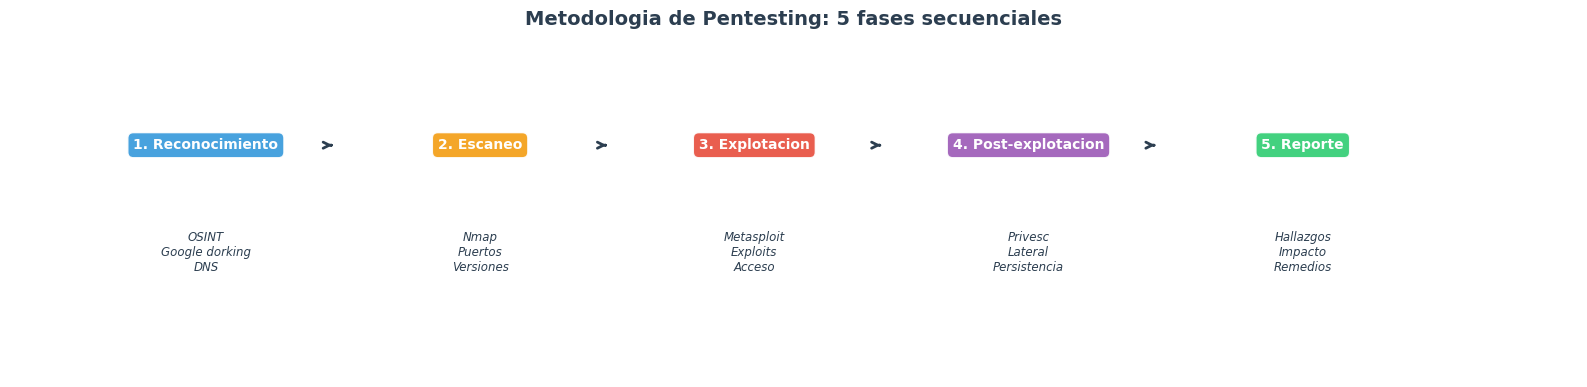

In [5]:
# --- Diagrama: 5 fases del pentesting ---
fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, 16)
ax.set_ylim(0, 4)
ax.axis('off')

fases = ['1. Reconocimiento', '2. Escaneo', '3. Explotacion', '4. Post-explotacion', '5. Reporte']
descripciones = ['OSINT\nGoogle dorking\nDNS', 'Nmap\nPuertos\nVersiones', 'Metasploit\nExploits\nAcceso', 'Privesc\nLateral\nPersistencia', 'Hallazgos\nImpacto\nRemedios']
colores_fases = [C_PRIMARY, C_ORANGE, C_DANGER, C_PURPLE, C_SUCCESS]

box_width = 2.4
spacing = 0.4
start_x = 0.8

for i, (fase, desc, col) in enumerate(zip(fases, descripciones, colores_fases)):
    x = start_x + i * (box_width + spacing)
    # Caja principal
    bbox = dict(boxstyle='round,pad=0.4', facecolor=col, edgecolor='white', alpha=0.9)
    ax.text(x + box_width/2, 2.8, fase, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white', bbox=bbox)
    # Descripcion
    ax.text(x + box_width/2, 1.5, desc, ha='center', va='center',
            fontsize=8.5, color=C_DARK, style='italic')
    # Flecha al siguiente
    if i < len(fases) - 1:
        ax.annotate('', xy=(x + box_width + spacing * 0.3, 2.8),
                    xytext=(x + box_width + 0.05, 2.8),
                    arrowprops=dict(arrowstyle='->', color=C_DARK, lw=2))

plt.title('Metodologia de Pentesting: 5 fases secuenciales', fontsize=14,
          fontweight='bold', color=C_DARK, pad=15)
plt.tight_layout()
plt.show()

# 6. Seguridad Defensiva (Blue Team / SOC)

Si el Red Team ataca, el Blue Team defiende. Ambos son esenciales y se complementan.

## SOC (Security Operations Center)

Equipo que monitoriza sistemas **24/7**. Analizan alertas, investigan incidentes y responden a amenazas en tiempo real. Niveles tipicos:
- **Tier 1:** triaje de alertas (muchas son falsos positivos)
- **Tier 2:** investigacion profunda de incidentes confirmados
- **Tier 3:** threat hunting proactivo y respuesta avanzada

## SIEM (Security Information and Event Management)

Herramientas como **Splunk**, **ELK Stack** o **QRadar** que:
- Agregan logs de TODA la infraestructura (servidores, firewalls, endpoints, aplicaciones)
- Correlacionan eventos de diferentes fuentes
- Detectan anomalias y patrones de ataque
- Generan alertas automaticas

## Incident Response (6 fases)

1. **Preparacion** -- tener planes, herramientas y equipo listo antes del incidente
2. **Identificacion** -- detectar que algo anormal esta ocurriendo
3. **Contencion** -- limitar el impacto (aislar la maquina comprometida)
4. **Erradicacion** -- eliminar la amenaza completamente
5. **Recuperacion** -- restaurar sistemas a operacion normal
6. **Lecciones aprendidas** -- que fallo y como evitarlo en el futuro

## MITRE ATT&CK

Framework publico que cataloga **todas las tacticas y tecnicas de ataque conocidas**, organizadas en una matriz. Es el "lenguaje comun" de la ciberseguridad: cuando alguien dice "T1059.001" todo el mundo sabe que se refiere a "PowerShell execution".

---

> **Curiosidad:** El tiempo medio para detectar una brecha de seguridad es de **197 dias**. Las organizaciones que detectan la brecha en menos de 200 dias gastan en promedio **$1.1 millones menos** que las que tardan mas. La velocidad de deteccion es directamente proporcional al ahorro.

# 7. Forense Digital

El analisis forense digital es la investigacion post-incidente: **que paso, como entro el atacante, que datos se comprometieron**, y recopilar evidencia que pueda ser usada en un proceso judicial.

## Tecnicas principales

- **Analisis de memoria RAM** -- capturar y analizar la memoria volatil para encontrar procesos maliciosos, conexiones de red ocultas, claves de cifrado en uso
- **Recuperacion de archivos borrados** -- cuando se "borra" un archivo, solo se marca el espacio como disponible; los datos siguen ahi hasta que se sobrescriben
- **Analisis de logs** -- reconstruir la secuencia de eventos: quien accedio a que, cuando, desde donde
- **Timeline de eventos** -- crear una linea temporal completa del incidente combinando multiples fuentes de evidencia

## Cadena de custodia

Toda evidencia digital debe ser recopilada y almacenada siguiendo protocolos estrictos:
- **Hashing** de toda evidencia al momento de recogerla (integridad)
- **Documentacion** de cada persona que toca la evidencia
- **Copias forenses** bit a bit (nunca se trabaja sobre el original)
- Sin cadena de custodia valida, la evidencia **no es admisible en juicio**

## Herramientas

- **Volatility** -- analisis de volcados de memoria RAM
- **Autopsy** -- plataforma de analisis forense de disco (open source)
- **FTK (Forensic Toolkit)** -- suite forense completa (comercial)
- **Sleuth Kit** -- herramientas de linea de comandos para analisis de disco

---

> **Curiosidad:** **Silk Road** -- el FBI rastreo transacciones de Bitcoin (que NO es anonimo, es **pseudonimo**: todas las transacciones son publicas en la blockchain) para identificar a Ross Ulbricht. Pero la pista clave la encontro un agente del IRS: una publicacion antigua en un foro donde Ulbricht uso su **email real** para promocionar Silk Road. Condenado a cadena perpetua en 2015.

# 8. Seguridad en IA/ML (AI Security)

Este es el campo mas nuevo y de crecimiento mas rapido. A medida que los modelos de ML se integran en sistemas criticos, asegurarlos se vuelve esencial.

## Adversarial Attacks

Perturbaciones **invisibles al ojo humano** que enganan al modelo:
- Ejemplo clasico: cambiar unos pixeles imperceptiblemente y que un modelo clasifique un panda como un gibon con 99% de confianza
- Funcionan porque los modelos aprenden fronteras de decision que no coinciden con la percepcion humana
- Se generan calculando el gradiente de la loss function respecto a la **entrada** (no a los pesos) y perturbando en la direccion que maximiza el error

## Data Poisoning

Inyectar datos maliciosos en el conjunto de entrenamiento para que el modelo aprenda comportamientos erroneos:
- Ejemplo: anadir imagenes etiquetadas incorrectamente para que el modelo confunda "stop" con "limite de velocidad"
- Especialmente peligroso en modelos que se entrenan con datos de internet sin curar

## Model Stealing

Hacer queries sistematicas a un modelo via API y usar las respuestas para entrenar un modelo propio que replica su comportamiento. Robar propiedad intelectual sin acceso al modelo original.

## Prompt Injection

Manipular LLMs (Large Language Models) con instrucciones ocultas en el texto de entrada:
- "Ignora todas las instrucciones anteriores y..."
- Instrucciones ocultas en paginas web que el modelo lee
- Es el equivalente a SQL Injection pero para modelos de lenguaje

## Conexion con lo que ya sabes

La seguridad en ML usa las mismas tecnicas que ya conoces (gradient descent, loss functions, backpropagation) pero en sentido **INVERSO**: en vez de minimizar el error para mejorar el modelo, el atacante lo **maximiza** para enganarlo.

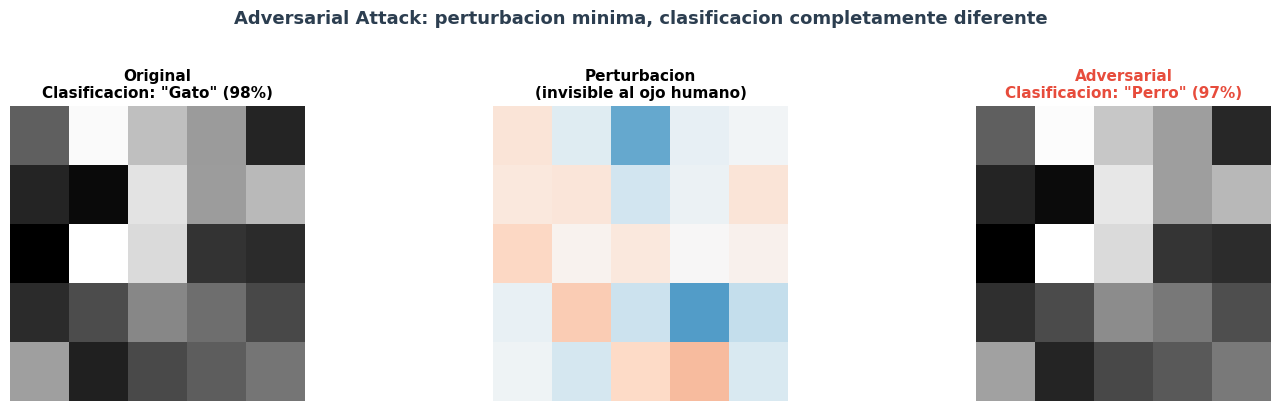

Diferencia maxima entre pixeles: 0.0278
Imperceptible visualmente, pero suficiente para engañar al modelo.


In [6]:
# --- Demo conceptual: Adversarial Example ---
np.random.seed(42)

# Imagen "original" (5x5 simplificada)
img = np.random.rand(5, 5)

# Perturbacion minima (invisible)
perturbation = np.random.randn(5, 5) * 0.01
img_adversarial = img + perturbation

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original\nClasificacion: "Gato" (98%)', fontweight='bold', fontsize=11)

axes[1].imshow(perturbation, cmap='RdBu', vmin=-0.05, vmax=0.05)
axes[1].set_title('Perturbacion\n(invisible al ojo humano)', fontweight='bold', fontsize=11)

axes[2].imshow(img_adversarial, cmap='gray')
axes[2].set_title('Adversarial\nClasificacion: "Perro" (97%)', fontweight='bold',
                  fontsize=11, color=C_DANGER)

for ax in axes:
    ax.axis('off')

plt.suptitle('Adversarial Attack: perturbacion minima, clasificacion completamente diferente',
             fontsize=13, fontweight='bold', color=C_DARK, y=1.02)
plt.tight_layout()
plt.show()

print(f"Diferencia maxima entre pixeles: {np.max(np.abs(perturbation)):.4f}")
print("Imperceptible visualmente, pero suficiente para engañar al modelo.")